In [1]:
include("../RayTracing.jl")
using FileIO

In [2]:
parsed_args = Dict(
        "scene-number" => 4,
        "render-simple" => false,
        "image-dim" => 150,
        "samples-per-pixel" => 2,
        "light-distribution-strategy" => "uniform",
        "file-name" => "yeehaw.png",
)

Dict{String, Any} with 6 entries:
  "samples-per-pixel"           => 2
  "image-dim"                   => 150
  "render-simple"               => false
  "file-name"                   => "yeehaw.png"
  "scene-number"                => 4
  "light-distribution-strategy" => "uniform"

In [11]:
passes = Vector{Array{Float64}}(undef, 5)
for (i, render_pass_flag) in enumerate([UInt8(0), UInt8(1), UInt8(2), UInt8(3), UInt8(4)])
    I, scene = RayTracing.build_scene(parsed_args)
    current_pass = RayTracing.render(
        I, 
        scene, 
        render_pass_flag,
        parsed_args["light-distribution-strategy"], 
    )
    FileIO.save("wtf_$(i).png", current_pass[end:-1:begin, :, :])
    passes[i] = current_pass
end


There are 37 objects in the scene, building BVH
  0.000276 seconds (2.60 k allocations: 195.656 KiB)
Done building BVH
Using 1 samples per pixel
There are 2 lights in the scene
Rendering 100 tiles
Utilizing 1 threads

Working on the full pass


Progress:   2%|▉                                        |  ETA: 0:00:05

Progress:   4%|█▋                                       |  ETA: 0:00:05

Progress:   6%|██▌                                      |  ETA: 0:00:06

Progress:   8%|███▍                                     |  ETA: 0:00:06

...

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00



There are 37 objects in the scene, building BVH
  0.000296 seconds (2.60 k allocations: 195.656 KiB)
Done building BVH
Using 1 samples per pixel
There are 2 lights in the scene
Rendering 100 tiles
Utilizing 1 threads

Working on the position pass


Progress:  29%|████████████                             |  ETA: 0:00:00

Progress:  57%|███████████████████████▎                 |  ETA: 0:00:00

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


# OK DENOISE

In [12]:
using Statistics

In [15]:
# extract channels
color_buffer = passes[1]  # full
albedo_buffer = passes[2]  # albedo
depth_buffer = passes[3]  # depth
normal_buffer = passes[4] # normal
position_buffer = passes[5] # position

filter_size = 10

10

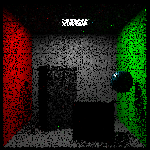

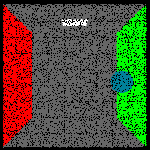

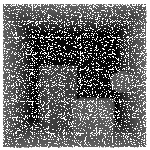

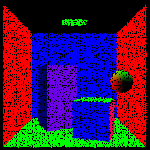

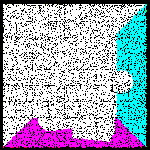

In [16]:
using Images
for buffer in [color_buffer, albedo_buffer, depth_buffer, normal_buffer, position_buffer]
    im = Images.colorview(RGB, PermutedDimsArray(buffer, (3,1,2)))
    display(im)
end

In [17]:
# filter size loop
loop_range = Int(trunc(log10(filter_size)/log10(2)))-1

2

In [18]:
function denoise_kernel2(
    color_buffer::Array{Float64}, 
    depth_buffer::Array{Float64},
    normal_buffer::Array{Float64},
    step_width::Int64
)::Array{Float64}
    # create output channel
    X, Y = size(color_buffer)
    out_buffer = zeros(X,Y,3)

    # define constants
    kernel = Float64[0.375, 0.25, 0.0625]
    c_phi = 0.45
    d_phi = 0.25
    n_phi = 0.40


    # pixel loop
    for x in 1:X
        for y in 1:Y
            c_val = RayTracing.Pnt3(color_buffer[x, y, :])
            d_val = RayTracing.Pnt3(depth_buffer[x, y, :])
            n_val = RayTracing.Pnt3(normal_buffer[x, y, :])

            # convolution loop
            total = RayTracing.Pnt3(0.0)
            cum_w = 0.0
            for dy in -2:2
                for dx in -2:2
                    x_temp = clamp(x + dx * step_width, 1, X)
                    y_temp = clamp(y + dy * step_width, 1, Y)

                    c_temp = RayTracing.Pnt3(color_buffer[x_temp, y_temp, :])
                    t = c_val - c_temp
                    dist2 = dot(t,t)
                    c_w = min(exp(-dist2 / c_phi), 1.0)

                    n_temp = RayTracing.Pnt3(normal_buffer[x_temp, y_temp, :])
                    t = n_val - n_temp
                    dist2 = max(dot(t,t)/(step_width * step_width), 0.0)
                    n_w = min(exp(-dist2 / n_phi), 1.0)

                    d_temp = RayTracing.Pnt3(depth_buffer[x_temp, y_temp, :])
                    t = d_val - d_temp
                    dist2 = dot(t,t)
                    d_w = min(exp(-dist2 / d_phi), 1.0)

                    weight = c_w * n_w * d_w
                    kernel_index = min(abs(dx), abs(dy))+1
                    total += c_temp * weight * kernel[kernel_index]
                    cum_w += weight * kernel[kernel_index]
                end
            end
            fin = total / cum_w
            out_buffer[x, y, 1] = fin.x
            out_buffer[x, y, 2] = fin.y
            out_buffer[x, y, 3] = fin.z
        end
    end
    return out_buffer
end

denoise_kernel2 (generic function with 1 method)

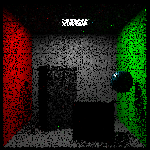

In [19]:
display(Images.colorview(RGB, PermutedDimsArray(color_buffer, (3,1,2))))

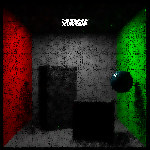

In [20]:
step_width = 2^0
color_buffer = denoise_kernel2(color_buffer, depth_buffer, normal_buffer, step_width)
display(Images.colorview(RGB, PermutedDimsArray(color_buffer, (3,1,2))))

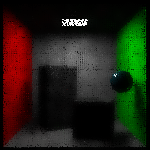

In [21]:
step_width = 2^1
color_buffer = denoise_kernel2(color_buffer, depth_buffer, normal_buffer, step_width)
display(Images.colorview(RGB, PermutedDimsArray(color_buffer, (3,1,2))))

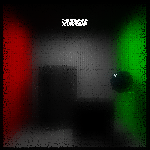

In [22]:
step_width = 2^2
color_buffer = denoise_kernel2(color_buffer, depth_buffer, normal_buffer, step_width)
display(Images.colorview(RGB, PermutedDimsArray(color_buffer, (3,1,2))))